## Находим цветной предмет в кадре с помощью OpenCV

Самое частое что надо сделать с помощью компьютерного зрения – это определить наличие и место определенного объекта в кадре. Для этого есть много разных методик, как очень простых так и очень сложных, но мы рассмотрим определение объекта по цвету.



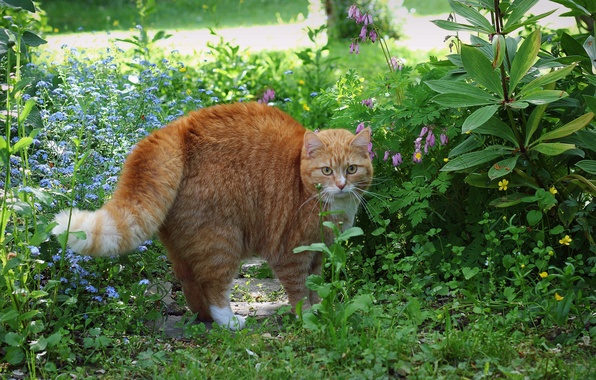

In [ ]:
cat_image = cv2.imread('kot-ryzhiy-trava-cvety.jpg')
cv2_imshow(cat_image)

Как мы можем видеть, в данном кадре есть большой и очень заметный кот. Как мы можем найти кота? Для начала мы можем оценить глазами, что цвет кота отличается от цвета окружения – он ярко рыжий и отлично виден в траве. Как мы можем выделить этот цвет в OpenCV? Для этого существует специальная функция **cv2.inRange()**, она принимает на вход изображение и диапазон цвета, который мы хотим выделить. На выходе мы получаем черно-белое изображение, где белым выделены пиксели, цвета которых попадали в диапазон, а черным – с цветом вне требуемого. Попробуем выделить на изображении кота:


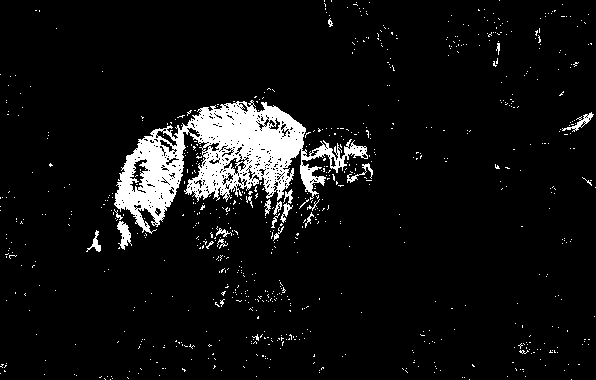

In [ ]:
low_red = (17,50,110)
high_red = (101,140,180)
only_cat = cv2.inRange(cat_image, low_red, high_red)
cv2_imshow(only_cat)

Используем функцию **cv2.inRange()**. Передаем ей изображение кота и два кортежа с определением верхней и нижней границы цвета. На выходе получаем черно-белое изображение, где пиксели со значением 255 соответствуют пикселям с цветом в искомом диапазоне, а значение 0 – всем остальным.

In [ ]:
#draw_image2(cat_image, only_cat)

С данным изображением мы уже можем работать, но что-то в нем не то. Кот выделен не целиком, и есть много лишних точек. Как вы могли заметить – мы работаем с изображением в пространстве **BGR**. Рассмотрим, что из себя представляет **BGR(RGB)**:

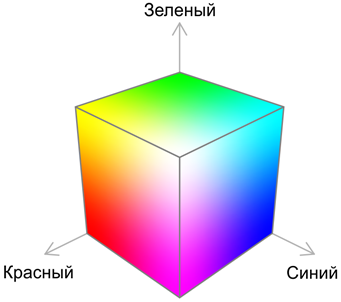

Это цветовое пространство представляет из себя куб с длинной стороны 256, где любой цвет задается координатами соответствующей точки на данном кубе. Данная концепция получила широкое распространение из-за того, что в случае формирования цвета на экране устройства, такого как телефон или монитор компьютера, изображение формируется за счет точек трех цветов – синего, зеленого, и красного. Теперь перейдем к нашей функции **cv2.inRange()**. Она принимает набор из двух цветов – точек на данном кубе. Что в таком случае мы будем считать за цвет, который удовлетворяет нашим критериям?

В таком случае в выделенный диапазон, который удовлетворяет нашим критериям, попадет цветовая область, схематично представляющая собой прямоугольный BGR-параллелепипед:

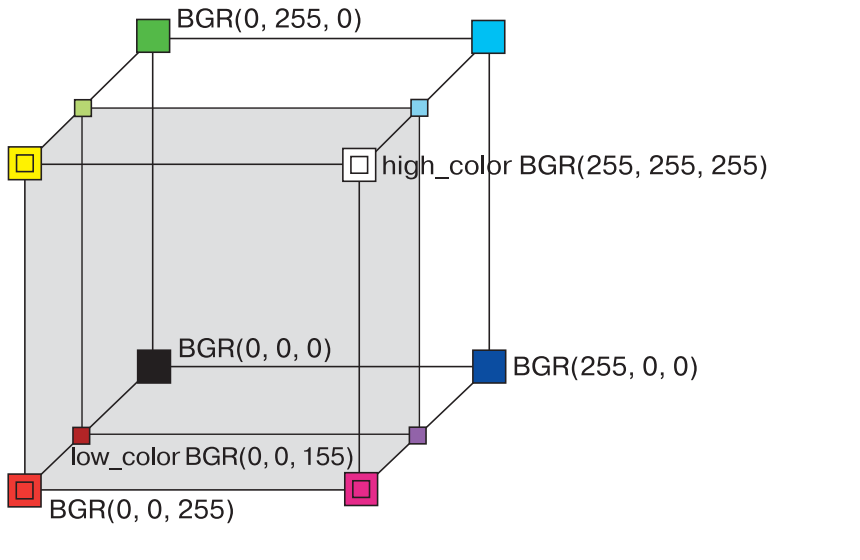

Таким образом, наша функция находит вложенный цветовой параллелепипед в полном кубе **BGR(RGB)**. И если требуется найти объект с оттенками, например, желтого цвета, то размещаем вложенный цветовой параллелепипед как можно ближе к желтой области. К сожалению, при таком размещении в указанный диапазон попадают и другие оттенки цветов, из-за того что грани параллелепипеда параллельны граням
основного куба **BGR(RGB)**. В результате на изображении, кроме пикселей
искомого объекта, появляются пиксели других цветов, не относящиеся к объекту.

Одно из существующих решений данной проблемы — это переход
в другое цветовое пространство. Наиболее эффективным здесь является **HSV (HSB)**-пространство. В данной модели основными координатами являются цветовой тон (**Hue**), насыщенность (**Saturation**)
и значение или яркость (**Value** или **Brightness**). Под **цветовым тоном H**
понимается именно цвет, измеряется от 0 до 360. **Насыщенность S** характеризует близость цвета к белому (розовый ближе к белому, чем красный). А параметр **значение V** представляет собой общую яркость точки — чем меньше, тем темнее. Схематично эту модель можно изобразить в виде перевернутого конуса:

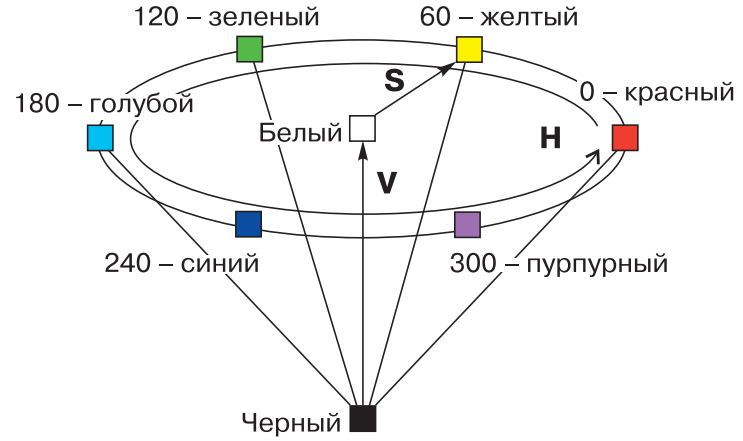

Диапазон выбранных цветов будет представлять область внутри **HSV**-конуса,
ограниченную нижними и верхними значениями параметров **H**, **S** и **V**. Например, так:

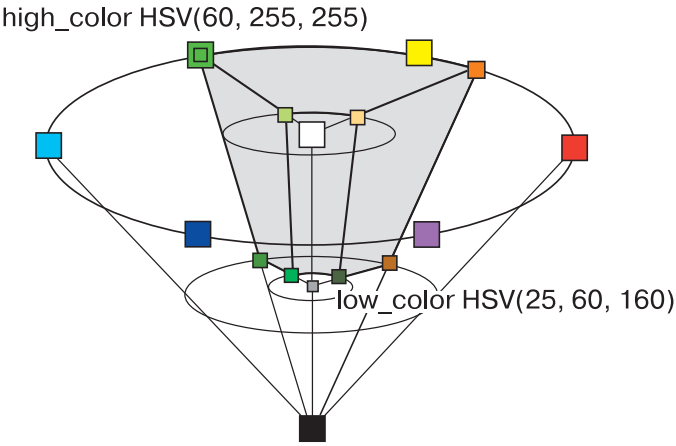

Границы **H** определяют основной диапазон цветов пикселей искомого объекта, **S** — насколько блеклые и насыщенные цвета пикселей объекта, а **V** — принадлежность к области темных и ярких оттенков.


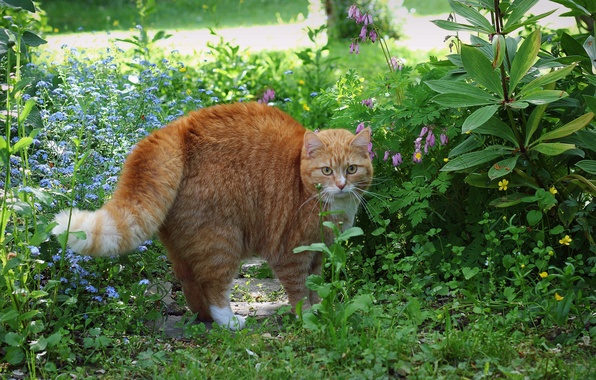

In [ ]:
cv2_imshow(cat_image)


Переведем наше изображение в **HSV** и снова найдем кота:

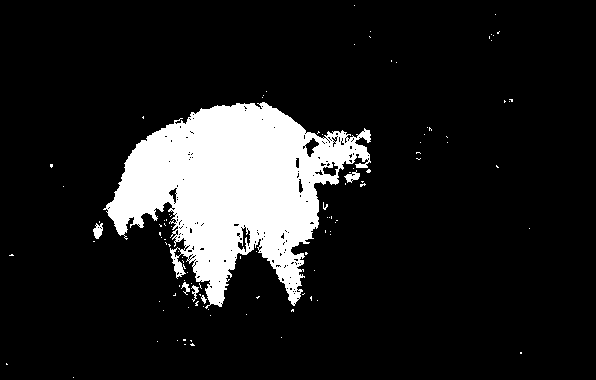

In [ ]:
cat_hsv = cv2.cvtColor(cat_image, cv2.COLOR_BGR2HSV) #Преобразуем в HSV
cat_color_low = (7,40,60) #Данный цвет - это темный ненасыщенный красный, близкий к бордовому
cat_color_high = (18,255,200) #Данный цвет - это светлый насыщенный оранжевый
only_cat_hsv = cv2.inRange(cat_hsv, cat_color_low, cat_color_high)
cv2_imshow(only_cat_hsv)

Как мы видим – шума стало значительно меньше, а кот определился значительно лучше.

Для поиска цветного объекта необходимо подобрать диапазон
`color_low = (H1,S1,V1), color_high = (H2,S2,V2)`. С помощью значений $H1, H2 (H1 < H2)$ определяются цветовые оттенки, в которые окрашен искомый объект. В OpenCV шкала цветового тона (**H**) лежит в значениях 0…180, шкалы (**S**) и (**V**) — в значениях 0…255. Для кодирования значений **H, S, V,** точно так же, как и для **RGB (BGR)** цветового пространства, используется по одному байту на каждую компоненту, что ограничивает пределы от 0 до 255. Поскольку в диаграмме число значений для компоненты **H** больше 255, для удобства пересчета пределы **H** ограничены от 0 до 180 и ее также можно кодировать одним байтом.



Далее запускаем программу и визуально оцениваем ее работу.
Сужая диапазоны за счет увеличения значений **S1** и **V1** и уменьшения значений **S2** и **V2**, а также расширяя или сужая интервал между
**H1** и **H2**, добиваемся удаления шума в изображении.




#### Определение координат найденного объекта
Итак, мы научились находить объекты на картинке
с помощью цветовых фильтров. Они получаются в виде черно-белых
изображений, на которых искомый объект окрашен в белый цвет,
а окружающий его фон — в черный.

Следующий шаг — определение положения объекта на картинке.
Это можно сделать, вычислив координаты искомого объекта. Поначалу эта задача может поставить в тупик, потому что объект, который мы хотим найти, — не точка на картинке, а целое пятно белого цвета и неправильной формы, состоящее из множества точек. Каждая точка имеет свою координату. Оперировать непосредственно таким множеством координат не очень удобно.

Для определения координат нашего «пятна», то есть объекта, в библиотеке OpenCV применяется функция вычисления моментов **cv2.moments()**.

*Пояснение*. [Момент изображения](https://en.wikipedia.org/wiki/Image_moment) — это суммарная характеристика пятна, представляющая собой сумму всех точек этого пятна. Существует множество подвидов моментов, характеризующих разные свойства изображения. Например, момент нулевого порядка **m00** — это количество всех точек, составляющих пятно (т.е. нулевой момент равен площади объекта). Моменты первого порядка: **m10** представляет собой сумму x-координат точек, а **m01** — сумму их y-координат. Имеются также моменты **m11**, **m20**, **m02**, **m22** и т.д.

Для работы функции **cv2.moments()** необходимо указать два аргумента:
* первый аргумент — имя переменной, с которой связано анализируемое изображение;
* второй аргумент — двоичное число, по значению которого определяется, как алгоритм должен вычислять вес каждой точки.

Мы в нашей задаче будем применять функцию **cv2.moments()**  к изображению, которое нам возвращает функция **cv2.inRange()**. А это изображение, точки которого кроме черного и белого цвета могут иметь градации серого цвета. Так вот, если значение второго аргумента для функции **cv2.moments()** равно 1, то вес всех точек с цветом, отличным от нуля, будет равен 1, вес черной точки будет равен 0, а белой точки — 255.

Для решения нашей задачи достаточно будет воспользоваться значениями моментов нулевого и первого порядков. Затем, поделив поочередно сумму x-координат (**m10**) и y-координат (**m01**) всех точек пятна на число его точек (**m00**), получим некоторые усредненные координаты нашего пятна по осям x и y (физически центроид – центр тяжести). Поскольку пятно является непосредственным отображением нашего объекта на отфильтрованном изображении, мы тем самым получаем координаты объекта на рисунке. Полученные таким образом координаты можно использовать, чтобы подписать найденный объект. В этом нам поможет еще одна функция из библиотеки OpenCV: **cv2.putText()**. А вот как это будет выглядеть в программном коде:

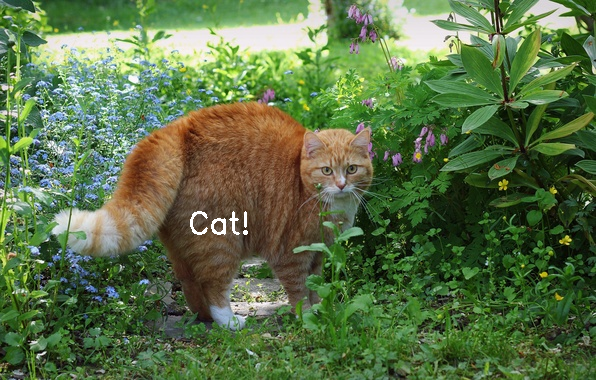

In [ ]:
moments = cv2.moments(only_cat_hsv, 1) # получим моменты
x_moment = moments['m01']
y_moment = moments['m10']
area = moments['m00']
x = int(x_moment / area) # Получим координаты x, y для кота
y = int(y_moment / area) # и выведем текст на изображение
cv2.putText(cat_image, "Cat!", (x,y), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2)

cv2_imshow(cat_image)

Следует обратить внимание на аргументы у функции **cv2.putText()**:  `cat_image` - выводимое изображение, `"Cat!"` - надпись по рассчитанным  ранее координатам `(x,y)`.

Для надписи используется шрифт **cv2.FONT_HERSHEY_SIMPLEX**, размер — 1, цвет —
белый в комбинации трех чисел (255,255,255), толщина линий букв — 2.

# Выделение контуров объектов с помощью OpenCV-Python

Рассмотрим следующий немаловажный инструмент машинного зрения — выделение
контуров объектов. Под контуром объекта понимается его видимый край, который разграничивает объект и фон. В большинстве методов анализ изображений состоит в работе с контурами, а не с пикселями. Совокупность методов выделения, описания и преобразования контуров изображения называется *контурным анализом*. Каждый контур хранится в виде двумерного массива библиотеки numpy.

Для поиска контуров в библиотеке OpenCV имеется функция
**cv2.findContours()**, которая возвращает два параметра: **contours**
и **hierarchy**. В общем виде функция имеет следующее представление:

`cv2.findContours (image, mode, method[,contours[, hierarchy[, off set]]])`

где аргументы означают следующее:


*   **image** — переменная, в которую записано графическое изображение, специально подготовленное для анализа. В данном случае для работы используется 8-битное монохромное изображение.
*   **mode** — режим группировки найденных контуров для управления их отображением. Таких режимов четыре:
  1. **cv2.RETR_LIST** — режим выдает все найденные контуры без группировки;

  2. **cv2.RETR_EXTERNAL** — режим выдает только крайние внешние контуры, а контуры, найденные внутри объекта, не отображаются;
  3. **cv2.RETR_CCOMP** — режим группировки контуров в двухуровневую иерархию:

      — на верхнем уровне — внешние контуры объекта,

      — на втором уровне — контуры имеющихся отверстий,

      — все остальные контуры группируются на верхнем уровне;

  4. **cv2.RETR_TREE** — режим группировки контуров в многоуровневую иерархию.

* **method** — способ хранения найденных контуров; выбирается
один из трех методов упаковки контуров:
  1. **cv2.CHAIN_APPROX_NONE** — упаковка не применяется, хранит абсолютно все точки контура, при этом любые две последующие точки контура являются соседями по горизонтали, вертикали или диагонали со смещением по координатам
не больше 1;
  2. **cv2.CHAIN_APPROX_SIMPLE** — метод склейки всех горизонтальных, вертикальных и диагональных сегментов контуров
с сохранением только их конечных точек, например для хранения вертикального прямоугольного контура будет использовано всего четыре точки;
  3. **cv2.CHAIN_APPROX_TC89_L1, cv2.CHAIN_APPROX_TC89_
KCOS** — для хранения контуров применяется метод упаковки **Teh-Chin** (Teh, C. H. and Chin, R. T., On the Detection of Dominant Points on Digital
Curve. PAMI 11 8, pp 859–872 (1989)).
* **contours** — (необязательный параметр) список всех обнаруженных контуров, представленных в виде векторов.
* **hierarchy** — (необязательный параметр) информация о топологии контуров: каждый элемент иерархии представляет собой сборку из четырех индексов, соответствующую `contours [i]`:
  1. `hierarchy [i] [0]` — индекс следующего контура на текущем слое;
  2. `hierarchy [i] [1]` — индекс предыдущего контура на текущем слое;
  3. `hierarchy [i] [2]` — индекс первого контура на вложенном слое;
  4. `hierarchy [i] [3]` — индекс родительского контура.

* **offset** — (необязательный параметр) величина дополнительного смещения, на которое смещается каждая точка контура. Этот параметр полезно применять, если контуры извлекаются из **ROI-изображения**, а затем должны быть проанализированы во всем контексте изображения.





*ПОЯСНЕНИЕ.* **Region Of Interest (ROI)** — представляет собой определенную
пользователем прямоугольную область на рисунке (Интересующая область рисунка — ИОР), которую можно выделить для дальнейшей обработки. После определения ИОР большинство функций OpenCV будет применяться к этой области. Это бывает полезно, когда нужно выполнить сравнения ИОР с каким-нибудь шаблоном (например, при распознавании объектов). ИОР должна обязательно находиться внутри исходного изображения.


После операции поиска контуров все найденные контуры необходимо отобразить. Визуализация найденных в кадре контуров выполняется с помощью функции **cv2.drawContours()**. Эта функция в большей степени необходима пользователю, поскольку позволяет лучше понять, как выглядят найденные контуры. В общем виде
функция **cv2.drawContours()** записывается следующим образом:

`cv2.drawContours(image, contours, contoursIdx, color[,thickness[, lineType[, hierarchy[, maxLevel[, off set]]]]])`


где аргументы означают следующее:

* **image** — переменная с изображением, поверх которого будут нарисованы контуры.
* **contours** — переменная, в которую записаны контуры, найденные функцией **cv2.findContours()**.
* **contoursIdx** — индекс контура, который следует отобразить;
если указанный индекс равен «–1», то отображаются все контуры.
* **color** — цвет линии контура, задается в виде тройки целочисленных значений ***(B, G, R)***, где каждая составляющая принимает
значение от 0 до 255.


* **thickness** — (необязательный параметр) толщина линии контура, задается целочисленным параметром; если задается отрицательное значение, например **thickness=CV_FILLED**, то будут рисоваться только внутренние (вложенные) контуры.
* **lineType** — (необязательный параметр) тип контурной линии;
в документации OpenCV указываются три значения:
  1. **8** (или не указан) — для рисования линии применяется 8-связный алгоритм Бресенхэма;
  2. **4** — для рисования линии применяется 4-связный алгоритм Бресенхэма;
  3. **cv2.LINE_AA** — рисуется сглаженная линия с применением гауссовой фильтрации.

* **hierarchy** — (необязательный параметр) информация об иерархии контуров, используется в случае, когда требуется нарисовать только некоторые контуры;
* **maxLevel** — (необязательный параметр) индекс слоя, который следует отображать:
  1. **0** — будет отображен только выбранный контур;
  2. **1** — будут отображены выбранный контур и все его дочерние контуры;
  3. **2** — будут отображены выбранный контур, все его дочерние контуры, дочерние контуры дочерних контуров и т. д.
* **offset** — (необязательный параметр) величина смещения точек
контура, задается парой целочисленных значений **(dx, dy)**.

Загрузим графическое изображение в формате ***jpeg***, а затем выполним поиск и отображение найденных контуров. Наша программа будет работать по следующему алгоритму:
1. Получить доступ к данным графического файла.
2. Перевести изображение в цветовое HSV-пространство.
3. Выделить объект с помощью цветового HSV-фильтра.
4. Выполнить поиск всех контуров.
5. Отобразить все найденные контуры на исходном изображении.
6. Вывести исходное изображение.

In [ ]:
import cv2 # импорт Open CV
from google.colab.patches import cv2_imshow # cv2_imshow служит для отображения картинок в Google Colab
import numpy as np
import os
import matplotlib.pyplot as plt

%matplotlib inline

Загрузка файлов в Google Colab

In [ ]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('Файл(ы) "{name}" размером {length} байт загружен(ы)'.format(
      name=fn, length=len(uploaded[fn])))

Saving Бублик одноцветный.jpg to Бублик одноцветный.jpg
Saving Бублик+прямоугольник.jpg to Бублик+прямоугольник.jpg
Saving Прямоугольники.png to Прямоугольники.png
Saving Эллипсы.png to Эллипсы.png
Файл(ы) "Бублик одноцветный.jpg" размером 14916 байт загружен(ы)
Файл(ы) "Бублик+прямоугольник.jpg" размером 22091 байт загружен(ы)
Файл(ы) "Прямоугольники.png" размером 50584 байт загружен(ы)
Файл(ы) "Эллипсы.png" размером 171963 байт загружен(ы)


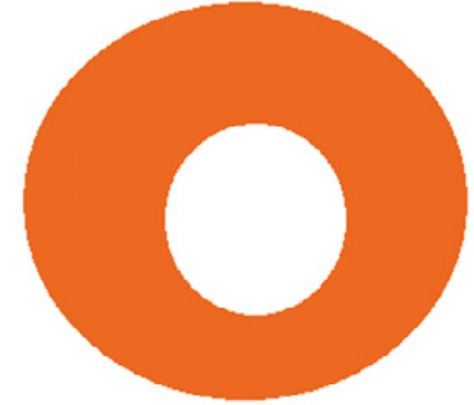

In [ ]:
fileName = 'Бублик одноцветный.jpg'

image = cv2.imread(fileName) # считываем данные графического файла в переменную image
cv2_imshow(image)

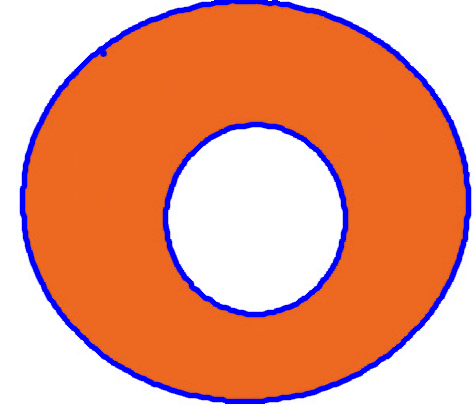

In [ ]:
hsv_img = cv2.cvtColor( image, cv2.COLOR_BGR2HSV )# конвертируем исходное изображение в цветовую модель HSV, результат записываем в переменную hsv_img

hsv_min = np.array((2, 28, 65), np.uint8) # подбираем параметры цветового фильтра для выделения нашего объекта (указанные числовые значения могут отличаться)
hsv_max = np.array((26, 238, 255), np.uint8)

hsv_msk = cv2.inRange( hsv_img, hsv_min, hsv_max ) # применяем цветовой фильтр к исходному изображению, результат записываем в переменную hsv_msk

# ищем контуры и записываем их в переменную contours в режиме поиска всех контуров без группировки cv2.RETR_LIST для хранения контуров используем
# метод cv2.CHAIN_APPROX_SIMPLE
contours, hierarchy = cv2.findContours(hsv_msk, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)


cv2.drawContours( image, contours, -1, (255,0,0), 3, cv2.LINE_AA, hierarchy, 2)# отображаем все контуры поверх исходного изображения, цвет синий, толщина линии 3, сглаженная

cv2_imshow(image)

# Выделение прямоугольных и эллиптических контуров

Следующим шагом в поиске контуров объектов на картинке является выделение контуров правильной геометрической формы. Здесь мы рассмотрим выделение прямоугольных и эллиптических контуров. Эта задача является более сложной. Кроме того, попутно изучим фильтрацию прямоугольных и эллиптических контуров, а также определение угла наклона прямоугольных контуров. Определение угла наклона прямоугольных контуров используется, например, при программировании роботов-манипуляторов для ситуаций, когда роботу нужно взяться за предмет под правильным углом.



## Выделение прямоугольных контуров

Для выделения прямоугольных контуров в OpenCV применяется функция **cv2.minAreaRect()**, цель которой — найти прямоугольник минимальной площади, способный описать заданный замкнутый контур. Важный момент: функция **cv2.minAreaRect()** не определяет, является ли контур прямоугольным; она пытается найти прямоугольник оптимальным способом, учитывая также его вращение.
В общем виде функция имеет следующее представление:

`cv2.minAreaRect(contour)`

где **contour** — это исходный контур, представляющий собой двухмерный массив numpy, который будет описан прямоугольником. Функция **cv2.minAreaRect()** возвращает объект, назовем его **rect**, в виде прямоугольника со следующими вещественными параметрами:
* координатами центра прямоугольника (x, y),
* размерами (ширина, высота),
* углом поворота в градусах.

Чтобы отобразить замкнутый прямоугольный контур, необходимо знать все вершины прямоугольника. Для их построения нам потребуется функция **cv2.boxPoints()**. Данная функция возвращает массив вещественных координат четырех точек — вершин прямоугольника. Общий вид этой функции:

`cv2.boxPoints(rect)`

где **rect** — объект, возвращаемый функцией **cv2.minAreaRect()**.


Для рисования прямоугольного контура следует округлить полученные координаты до целых значений. Это можно сделать с помощью функции **numpy.int0()**, которая на входе получает вещественный массив, а возвращает целочисленный. Массив координат вершин прямоугольника, преобразованный таким образом, рисуем с помощью функции **cv2.drawContours()**.

Напишем программу, которая все найденные на картинке контуры объекта обозначит прямоугольниками. Поскольку за основу мы берем предыдущую программу, алгоритм
будет иметь некоторое сходство, но содержать несколько иную последовательность действий:
1. Получить доступ к данным графического файла.
2. Перевести изображение в цветовое HSV-пространство.
3. Выделить объект с помощью цветового HSV-фильтра.
4. Выполнить поиск всех контуров.
5. Начать цикл по всем найденным контурам.
6. Найти прямоугольник, описывающий текущий контур.
7. Отобразить полученный нами прямоугольник на исходном изображении.
8. Закончить цикл.
9. Вывести на экран окно с исходным изображением.


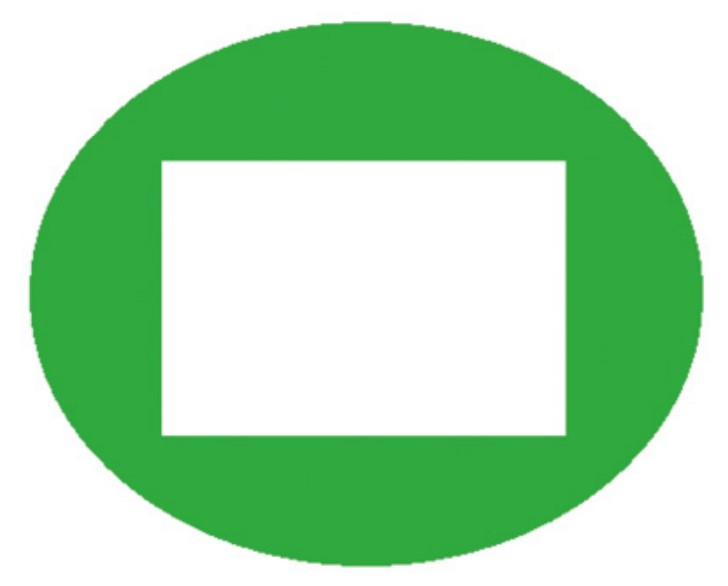

In [ ]:
fileName = 'Бублик+пямоугольник.jpg'

image = cv2.imread(fileName) # считываем данные графического файла в переменную image

cv2_imshow(image)

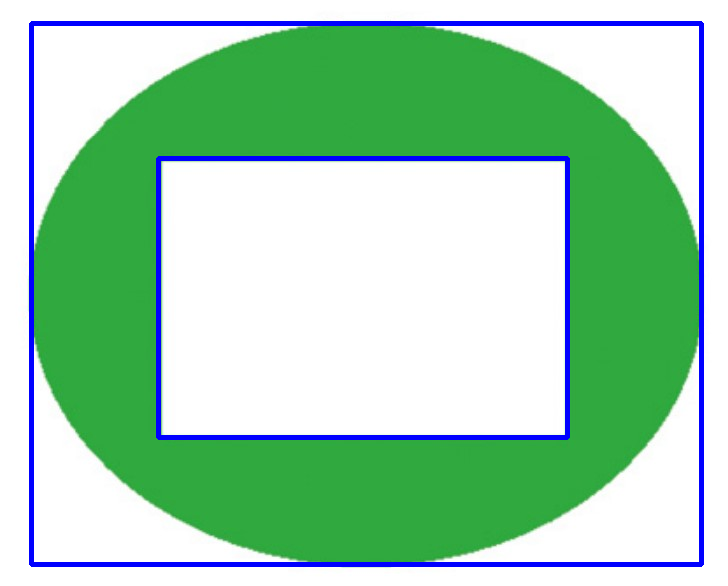

In [ ]:
hsv_img = cv2.cvtColor( image, cv2.COLOR_BGR2HSV )# конвертируем исходное изображение в цветовую модель HSV, результат записываем в переменную hsv_img

hsv_min = np.array((50, 150, 155), np.uint8) # подбираем параметры цветового фильтра для выделения нашего объекта (указанные числовые значения могут отличаться)
hsv_max = np.array((70, 255, 200), np.uint8)

hsv_msk = cv2.inRange( hsv_img, hsv_min, hsv_max ) # применяем цветовой фильтр к исходному изображению, результат записываем в переменную hsv_msk

# ищем контуры и записываем их в переменную contours в режиме поиска всех контуров без группировки cv2.RETR_LIST для хранения контуров используем
# метод cv2.CHAIN_APPROX_SIMPLE
contours, hierarchy = cv2.findContours(hsv_msk, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)


# перебираем все найденные контуры в цикле
for icontour in contours:

  rect = cv2.minAreaRect(icontour) # ищем прямоугольник, результат записываем в rect

  box = cv2.boxPoints(rect) # поиск вершин прямоугольника, результат записываем в box

  box = np.int0(box) # округление координат вершин, результат записываем в box

  # рисуем прямоугольник поверх исходного изображения цвет синий, толщина линии 3, поскольку рисуем
  # единственный объект [box], остальные параметры опускаем
  cv2.drawContours(image, [box], -1, (255, 0, 0), 3)

cv2_imshow(image)

В результате работы программы было выделено два прямоугольных контура. Внутренний контур полностью совпадает с прямоугольной границей объекта, а внешний прямоугольный контур описывает овальную границу объекта, причем, хотя и не совпадает с ней, описывает максимально близко. Как видим, функция **cv2.minAreaRect()** построила прямоугольный контур, который максимально близко описывает непрямоугольную границу.

### Фильтрация прямоугольных контуров

Зачастую на практике при выделении контуров «нужных объектов» в силу ряда причин заодно могут быть выделены и контуры «ложных объектов» — «шум». Как правило, это мелкие области, от которых для дальнейшего анализа необходимо избавиться. Такой «шум» следует отфильтровать, чтобы программа при отображении
контуров его игнорировала.

Решается эта задача путем вычисления площади, занимаемой каждым контуром, а затем при отображении ставится условие для контуров, площадь которых не соответствует заданному критерию. Поскольку наши контуры — это прямоугольники, то вычислить их площадь не составит труда. Для этого надо перемножить ширину и высоту. Значения ширины и высоты прямоугольников получим из функции **cv2.minAreaRect()**. В числе параметров, возвращаемых этой функцией, есть необходимые данные. Вспомним структуру объекта, возвращаемого функцией
**cv2.minAreaRect()**. Это массив, содержащий три! элемента:
* координаты центра прямоугольника,
* его размеры (ширина и высота),
* угол поворота,

то есть `(x, y), (w, h), a`.

Далее нам надо получить доступ к паре `(w, h)`. Ранее результат работы функции **cv2.minAreaRect()** мы сохраняли в переменную **rect**, значит, искомые значения будут находиться в ячейках массива по адресу `rect[1][0] и rect[1][1]`.
Перемножив эти значения, получим площадь текущего прямоугольника. Если значение
площади отвечает заданному критерию, то этот контур нам интересен и мы его рисуем. Таким образом, чтобы отфильтровывать только нужные контуры,
необходимо модифицировать программу выделения прямоугольных
контуров следующим фрагментом из двух строчек:
```
..
area = int(rect[1][0]*rect[1][1]) # вычисление площади
if area > 1500: # если площадь больше указанного значения..
..
```
Добавим эти две строчки сразу после строки с функцией **cv2.minAreaRect()**.



Выведем на экран контуры больших прямоугольников светло-синего цвета. За основу берем предыдущую программу и подберем нужный цветовой фильтр.

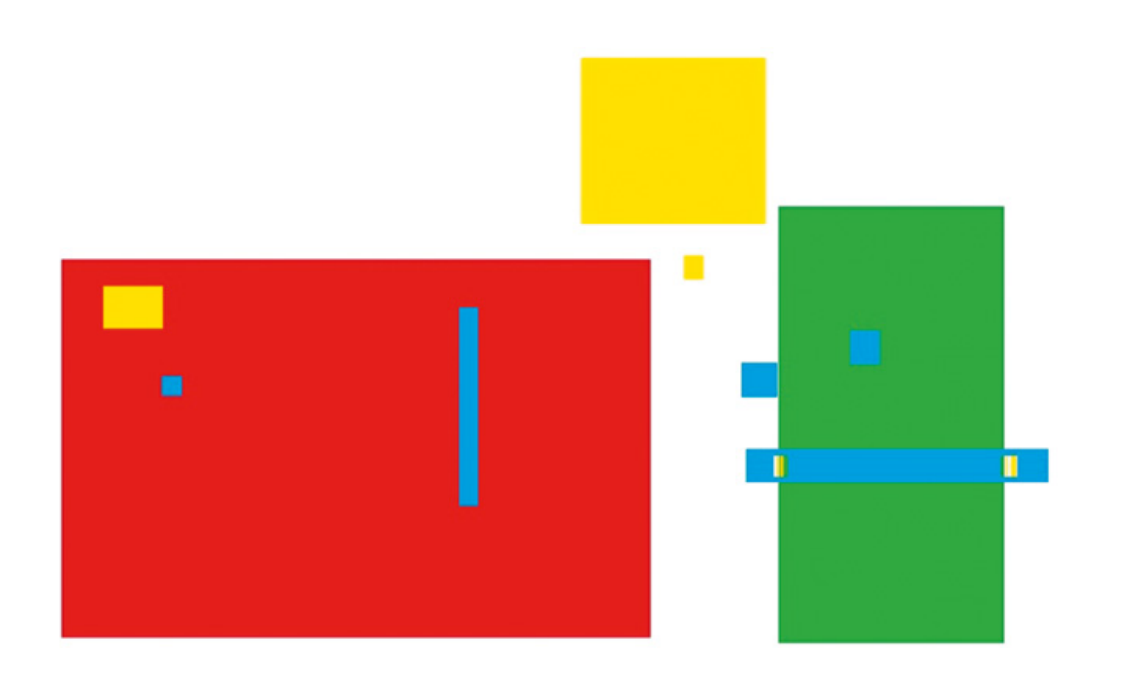

In [ ]:
fileName = 'Прямоугольники.png'

image = cv2.imread(fileName) # считываем данные графического файла в переменную image

cv2_imshow(image)

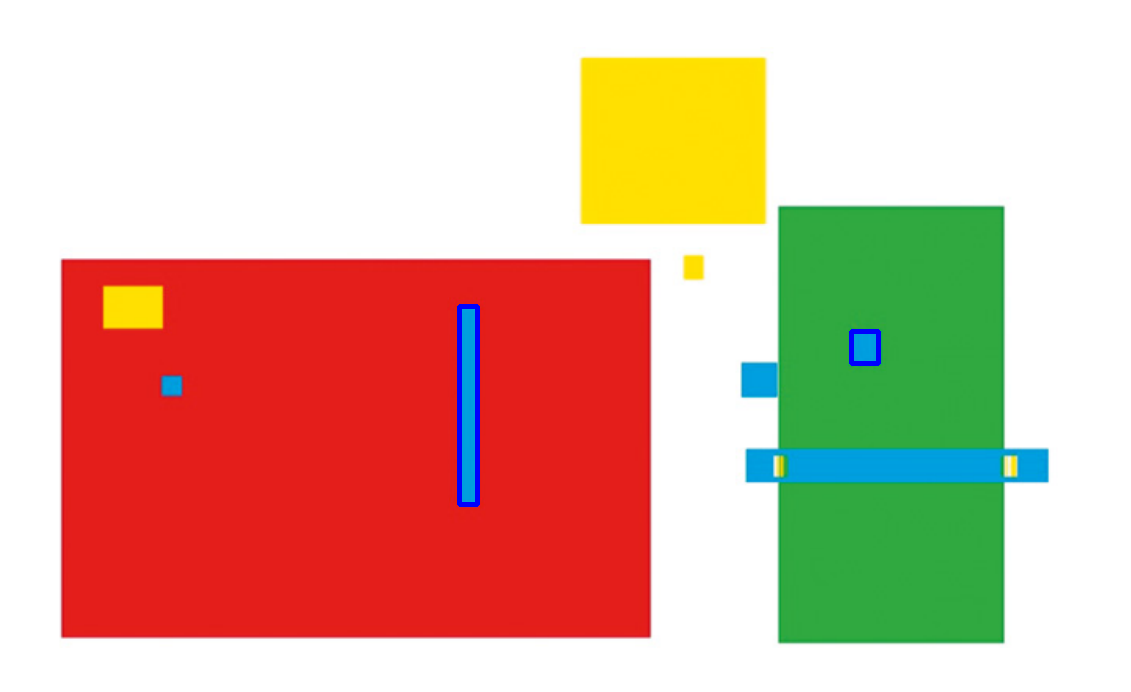

In [ ]:
hsv_img = cv2.cvtColor( image, cv2.COLOR_BGR2HSV )# конвертируем исходное изображение в цветовую модель HSV, результат записываем в переменную hsv_img

hsv_min = np.array((90, 100, 100), np.uint8) # подбираем параметры цветового фильтра для выделения нашего объекта (указанные числовые значения могут отличаться)
hsv_max = np.array((120, 255, 200), np.uint8)

hsv_msk = cv2.inRange( hsv_img, hsv_min, hsv_max ) # применяем цветовой фильтр к исходному изображению, результат записываем в переменную hsv_msk

# ищем контуры и записываем их в переменную contours в режиме поиска всех контуров без группировки cv2.RETR_LIST для хранения контуров используем
# метод cv2.CHAIN_APPROX_SIMPLE
contours, hierarchy = cv2.findContours(hsv_msk, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)


for icontour in contours: # перебираем все найденные контуры в цикле

  rect = cv2.minAreaRect(icontour) # ищем прямоугольник, результат записываем в rect

  area = int(rect[1][0]*rect[1][1]) # вычисление площади
  if area > 500: # если площадь больше указанного значения, эти контуры выводим, значение подбираем экспериментально

      box = cv2.boxPoints(rect) # поиск вершин прямоугольника, результат записываем в box

      box = np.int0(box) # округление координат вершин, результат записываем в box

      # рисуем прямоугольник поверх исходного изображения цвет синий, толщина линии 3, поскольку рисуем
      # единственный объект [box], остальные параметры опускаем
      cv2.drawContours(image, [box], -1, (255, 0, 0), 3)

cv2_imshow(image)

Как видите, фильтровать «графический сор» совсем несложно. Из представленного
рисунка можно заметить, что не все светло-синие объекты выделены
контурами. Меняя параметры цветового фильтра и значение площади
прямоугольника в условии отбора, нетрудно выполнить эту же задачу
для объектов других цветов. Таким же образом можно фильтровать
прямоугольные контуры, учитывая соотношение сторон, периметр, задавая определенный диапазон значений по размерам и т. д.


## Выделение и фильтрация эллиптических контуров

Для выделения эллиптических контуров в OpenCV применяется функция **cv2.fitEllipse()**. Как и функция **cv2.inAreaRect()**, функция **cv2.fitEllipse()** не сможет отличить на картинке объект с действительно эллиптическим контуром от объекта с прямоугольным контуром. Эта функция лишь пытается вписать эллипс в любой контур с количеством точек, большим или равным 5. Чуть позже мы
увидим, как функция **cv2.fitEllipse()** попытается описать объект
неэллиптической формы. Результатом работы данной функции, согласно документации, является повернутый прямоугольник, в который вписан эллипс.

В общем виде функция **cv2.fitEllipse()** записывается следующим образом:

`cv2.fitEllipse(contour)`

где **contour** — это контур, представляющий собой двухмерный массив numpy, в который будет вписан эллипс.

Чтобы нарисовать найденный эллиптический контур, воспользуемся функцией **cv2.ellipse()**. Общий вид данной функции имеет два определения. Нам понадобится определение с альтернативным представлением эллипса, когда отображаемый эллипс вписан в повернутый прямоугольник:

`cv2.ellipse(img, box, color[, thickness[, lineType]])`

где **img** — переменная с изображением;

**box** — альтернативное представление эллипса (эллипс вписан в повернутый прямоугольник);

**color** — цвет эллипса, задается комбинацией значений (B, G, R);

**thickness** — толщина линии в пикселях (необязательный параметр);

**lineType** — тип линии (необязательный параметр).

Задача фильтрации реализуется путем вычисления длины эллиптического контура. Далее, указав необходимые условия, мы можем отображать нужные нам контуры. Для вычисления длины контура применим функцию **len()**. Эта функция возвращает число элементов в массиве. Если в качестве аргумента функции **len()** мы укажем конкретный контур (а он представляет собой массив точек!), то получим его длину в точках.

Алгоритм программы поиска эллиптических контуров очень похож
на алгоритм поиска прямоугольных контуров, приведем его еще раз
в словесной форме:
1. Получить доступ к данным графического файла.
2. Перевести изображение в цветовое HSV-пространство.
3. Выделить объект с помощью цветового HSV-фильтра.
4. Выполнить поиск всех контуров.
5. Начать цикл по всем найденным контурам.
6. Найти эллипс, описывающий текущий контур.
7. Отобразить полученный эллипс на исходном изображении.
8. Закончить цикл.
9. Вывести на экран окно с исходным изображением.


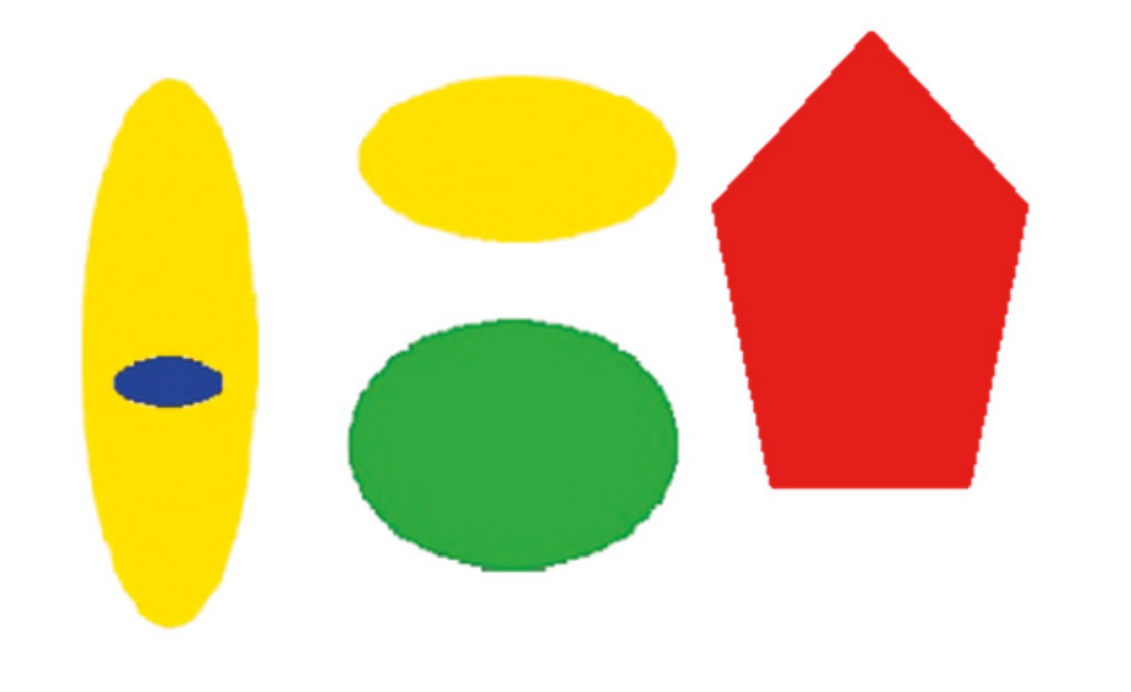

In [ ]:
fileName = 'Эллипсы.png'

image = cv2.imread(fileName) # считываем данные графического файла в переменную image

cv2_imshow(image)

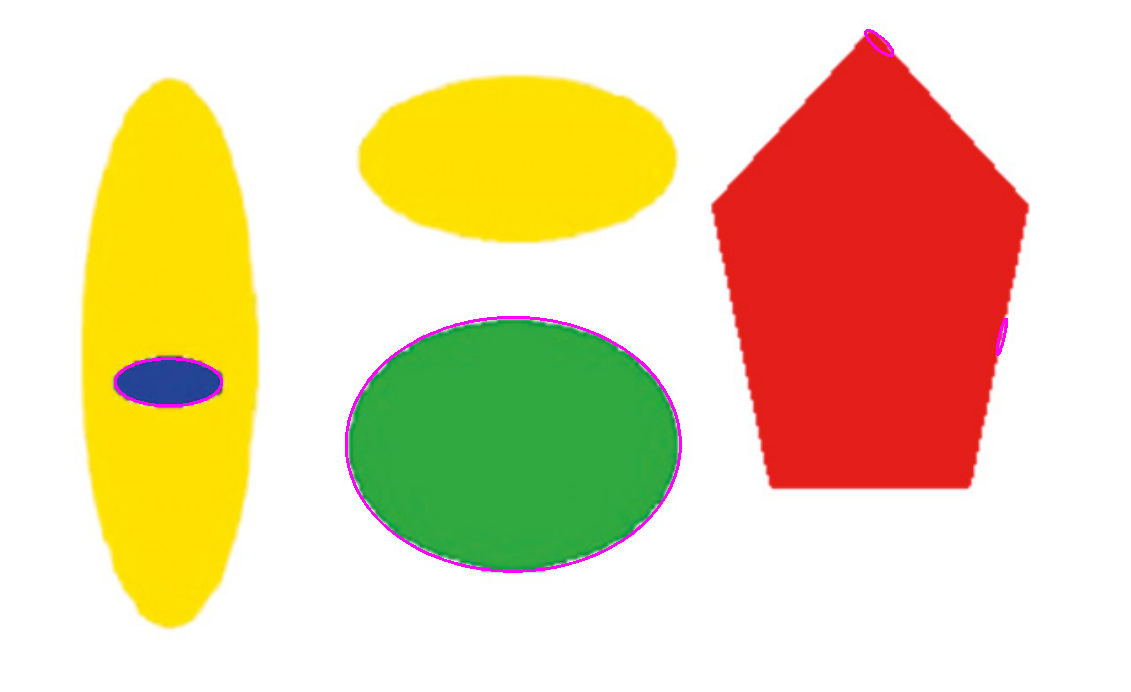

In [ ]:
hsv_img = cv2.cvtColor( image, cv2.COLOR_BGR2HSV )# конвертируем исходное изображение в цветовую модель HSV, результат записываем в переменную hsv_img

hsv_min = np.array((60, 10, 10), np.uint8)# подбираем параметры цветового фильтра для выделения нашего объекта (указанные числовые значения могут отличаться)
hsv_max = np.array((180, 255, 255), np.uint8)

hsv_msk = cv2.inRange( hsv_img, hsv_min, hsv_max ) # применяем цветовой фильтр к исходному изображению, результат записываем в переменную hsv_msk

# ищем контуры и записываем их в переменную contours в режиме поиска всех контуров без группировки cv2.RETR_LIST для хранения контуров используем
# метод cv2.CHAIN_APPROX_SIMPLE
contours, hierarchy = cv2.findContours(hsv_msk, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)


for icontour in contours: # перебираем все найденные контуры в цикле
  if len(icontour)>40:# выбираем контуры с длиной больше 40 точек
    ellipse = cv2.fitEllipse(icontour)# записываем в переменную ellipse, отвечающий условию контур в форме эллипса
    cv2.ellipse(image, ellipse, (255,0,255), 2)# отображаем найденный эллипс

cv2_imshow(image)

Как видим, на рисунке эллиптическими контурами описаны не только эллиптические объекты. И в то же время не все эллиптические объекты помечены контуром. Интересно, почему?
Если приглядимся повнимательнее, то увидим, что желтые овалы остались без контуров. Заглянув в параметры цветового фильтра, мы обнаружим, что желтый цвет находится за пределами границ фильтра. Выведем маску фильтра, в котором нет «следов» желтых овалов:

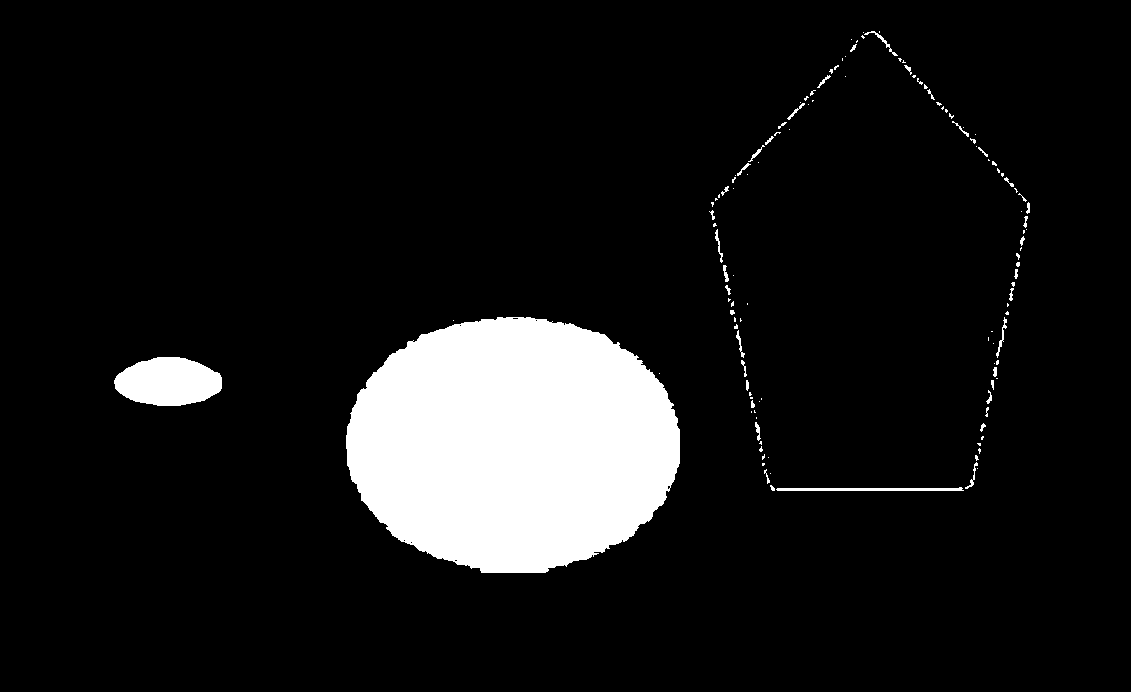

In [ ]:
fileName = 'Эллипсы.png'

image = cv2.imread(fileName) # считываем данные графического файла в переменную image
hsv_img = cv2.cvtColor( image, cv2.COLOR_BGR2HSV )# конвертируем исходное изображение в цветовую модель HSV, результат записываем в переменную hsv_img

hsv_min = np.array((60, 10, 10), np.uint8)# подбираем параметры цветового фильтра для выделения нашего объекта (указанные числовые значения могут отличаться)
hsv_max = np.array((180, 255, 255), np.uint8)

hsv_msk = cv2.inRange( hsv_img, hsv_min, hsv_max ) # применяем цветовой фильтр к исходному изображению, результат записываем в переменную hsv_msk
cv2_imshow(hsv_msk)

 # Использование OpenCV для измерения размера объектов на изображении


**Основная идея:**

Ранее мы рассмотрели немаловажный инструмент машинного зрения — выделение
контуров объектов. После того, как объект на изображении найден и оконтурен, можно попытаться оценить его геометрические размеры, если в поле зрения находится *калибровочный предмет* с известными размерами. Тогда, выяснив соотношение между реальными размерами этого предмета в единицах длины и его размерами на изображении в пикселях, можно приближенно вычислить размеры остальных измеряемых объектов на изображении.

Итак, наш калибровочный (эталонный) объект должен иметь два важных атрибута:

* Мы должны знать *истинный* размер этого объекта (эквивалентный размер в миллиметрах или сантиметрах по ширине или высоте).
* Мы должны быть в состоянии легко найти этот эталонный объект на изображении, либо на основе позиции эталонного объекта (например, эталонный объект может быть объектом в верхнем левом углу изображения), либо на основе внешнего вида эталонного объекта (например, эталонный объект может быть на картинке с самым уникальным цветом или уникальной формой, отличаясь от всех других объектов), т.е. наш эталон должен быть однозначно идентифицируем.

В этом примере мы будем использовать 2х-рублевую монету диаметром **23 мм** в качестве калибровочного предмета, и это будет самый левый объект в нашем изображении.

In [ ]:
import cv2 # импорт Open CV
from google.colab.patches import cv2_imshow # cv2_imshow служит для отображения картинок в Google Colab
import numpy as np
from scipy.spatial import distance as dist
from imutils import perspective
from imutils import contours
import argparse
import imutils
import matplotlib.pyplot as plt

%matplotlib inline

Загрузка файлов в Google Colab

In [ ]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('Файл(ы) "{name}" размером {length} байт загружен(ы)'.format(
      name=fn, length=len(uploaded[fn])))

Saving example1.jpg to example1.jpg
Файл(ы) "example1.jpg" размером 41904 байт загружен(ы)


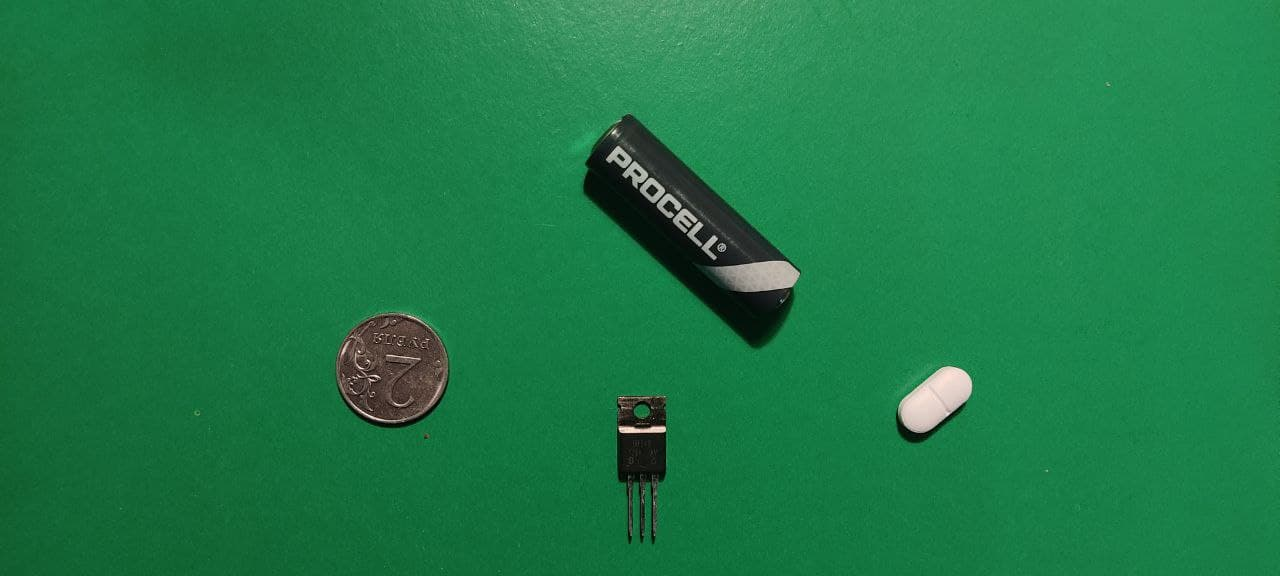

In [ ]:
еfileName = 'example1.jpg'

image = cv2.imread(fileName) # считываем данные графического файла в переменную image
cv2_imshow(image)

Теперь мы можем расположить области контуров имеющихся на изображении объектов слева направо и захватить эту монету (она всегда будет соответствовать первой области контура в отсортированном списке), и использовать ее размер, чтобы определить соотношение

`pix_per_metric = ширина пикселя объекта / реальная ширина объекта`


Далее применим этот подход. Загруженное изображение преобразуем в градации серого и немного размоем с помощью фильтра Гаусса:


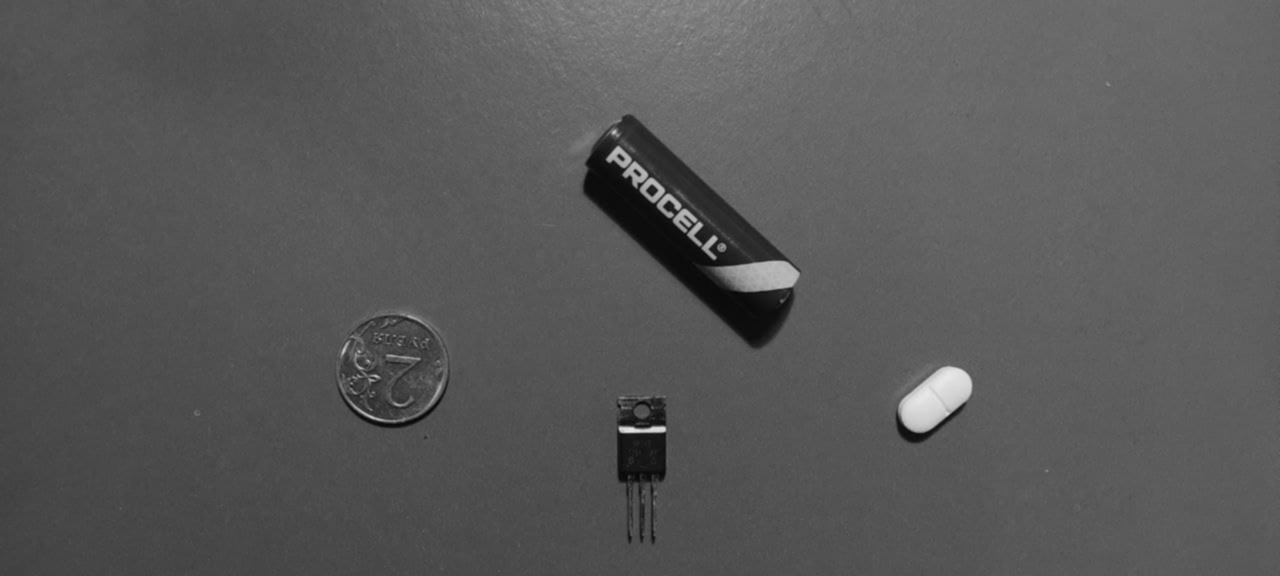

In [ ]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) # Преобразование в градации серого. openCV  оперирует палитрой BGR

gray = cv2.GaussianBlur(gray, (3, 3), 0) # Фильтр Гаусса с маской 3х3. Отсутствие размытия зачастую дает детекцию ложных объектов

cv2_imshow(gray)

Теперь обнаружим края с использованием детектора Канни:

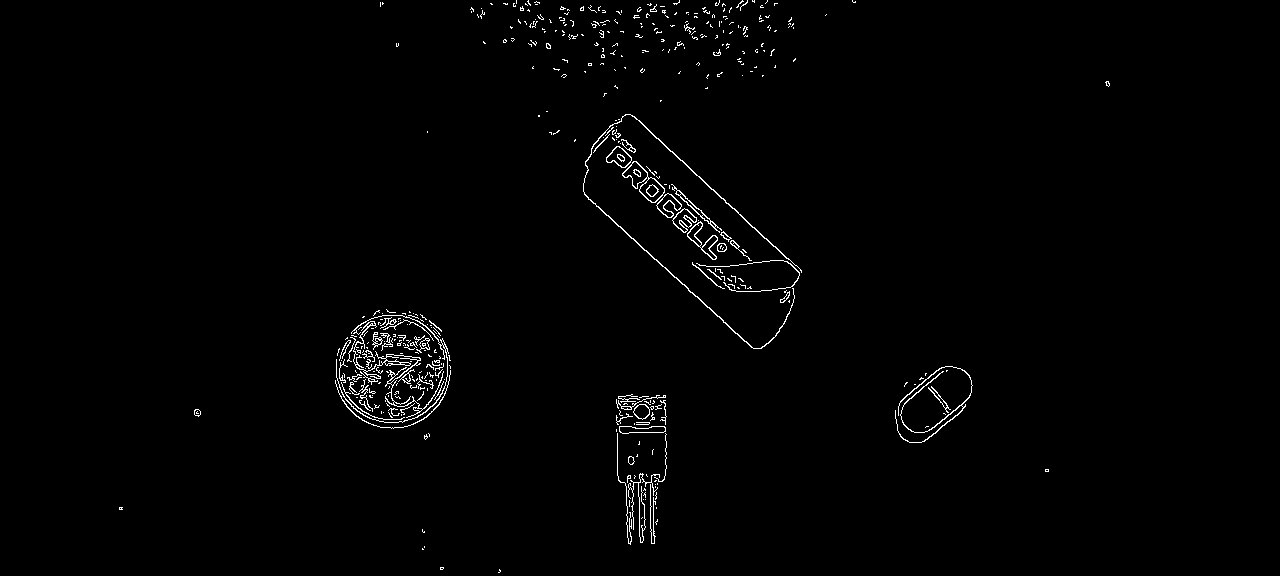

In [ ]:
edged = cv2.Canny(gray, 50, 70) # Обнаруживаем края.
cv2_imshow(edged)

Теперь последовательно выполним морфологические операции дилатации и эрозии для получения более четких краев:

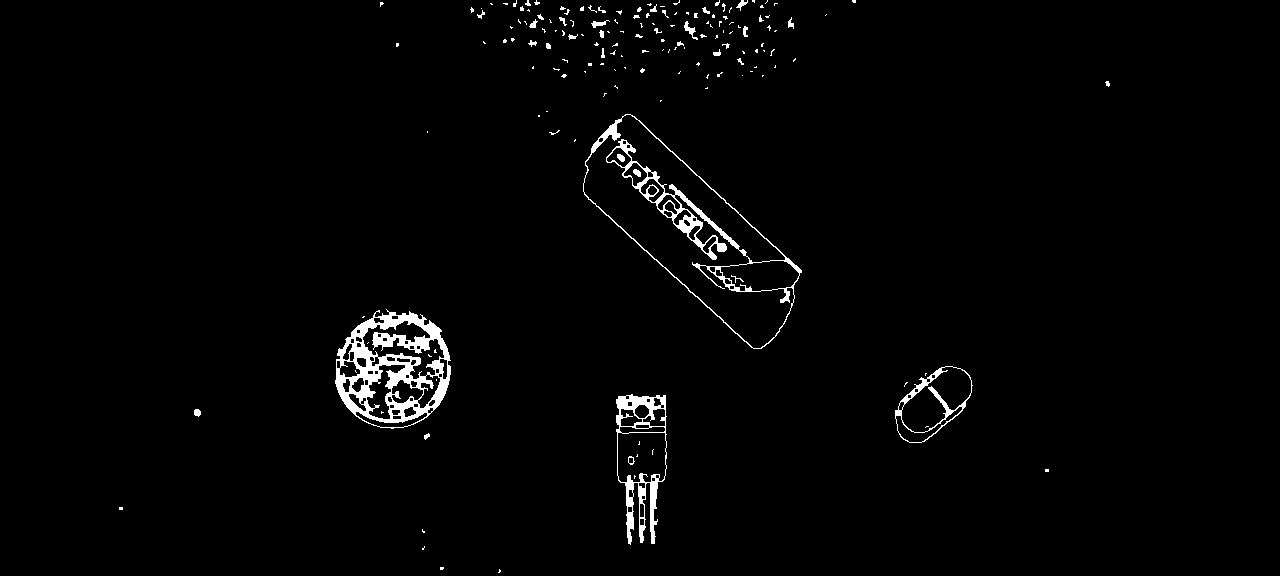

In [ ]:
edged = cv2.erode(cv2.dilate(edged, None, iterations=1), None, iterations=1)# Выполняем дилатацию и эрозию, чтобы  получить четкие края
cv2_imshow(edged)

Поскольку нас интересуют измерения внешних размеров, то внутренние контуры нам не интересны. Соответсвенно, вызовем метод **cv2.findContours()** с подходящими параметрами для полученного изображения:

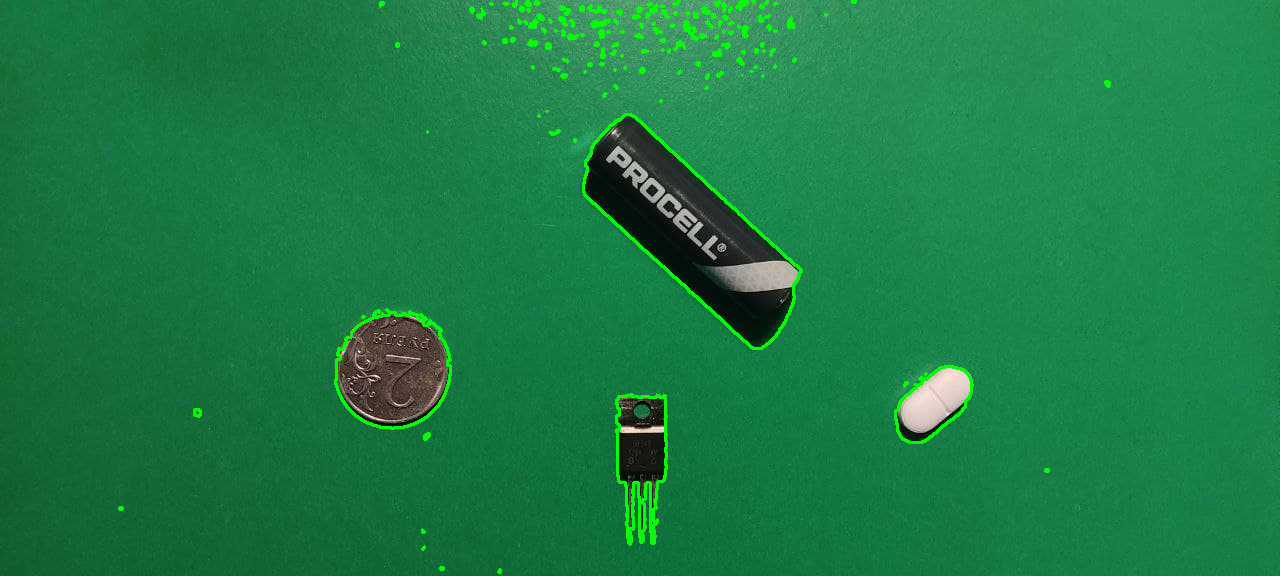

In [ ]:
# RETR_EXTERNAL -  находит только внешние контуры, CV_CHAIN_APPROX_SIMPLE — склеивает все горизонтальные, вертикальные и диагональные контуры.
cnts = cv2.findContours(edged, cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
cnts = cnts[0] if len(cnts) == 2 else cnts[1]

(cnts, _) = contours.sort_contours(cnts) # сортируем найденные контуры в порядке слева направо, для определения эталонного (левого) объекта

# визуализация найденных контуров
cnts_image = image.copy()
cv2.drawContours(cnts_image, cnts, -1, (0, 255, 0), 2)
cv2_imshow(cnts_image)

Очевидно, что на рисунке имеется большое количество неинтересных нам мелких областей. Если область контура недостаточно велика, разумно ее отбросить, считая шумом.

Если площадь контура достаточно велика, мы вычислим ограничивающий ее угол поворота изображения.

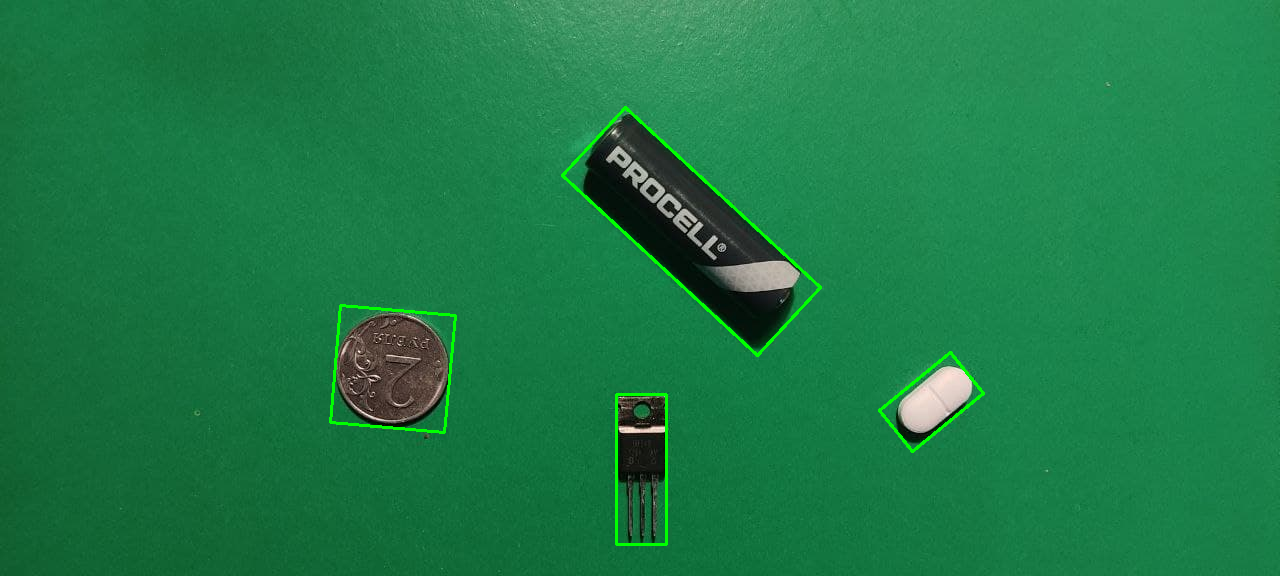

In [ ]:
orig = image.copy()
for c in cnts:
    if cv2.contourArea(c) < 1000:# пропускаем маленькие контуры
        continue

    box = cv2.minAreaRect(c)# вычисляем рамку ограничивающую контур

    box = cv2.cv.BoxPoints(box) if imutils.is_cv2() else cv2.boxPoints(box)# определяем углы

    box = perspective.order_points(box) # сортируем координаты по часовой стрелке

    cv2.drawContours(orig, [box.astype("int")], -1, (0, 255, 0), 2) # рисуем рамку, openCV  оперирует палитрой BGR

cv2_imshow(orig)

Определим средние точки и проведем средние линии для ограничивающих прямоугольников, дополнив предыдущий код:

In [ ]:
def midpoint(ptA, ptB):# функция вычисления средней точки
   return ((ptA[0] + ptB[0]) * 0.5, (ptA[1] + ptB[1]) * 0.5)

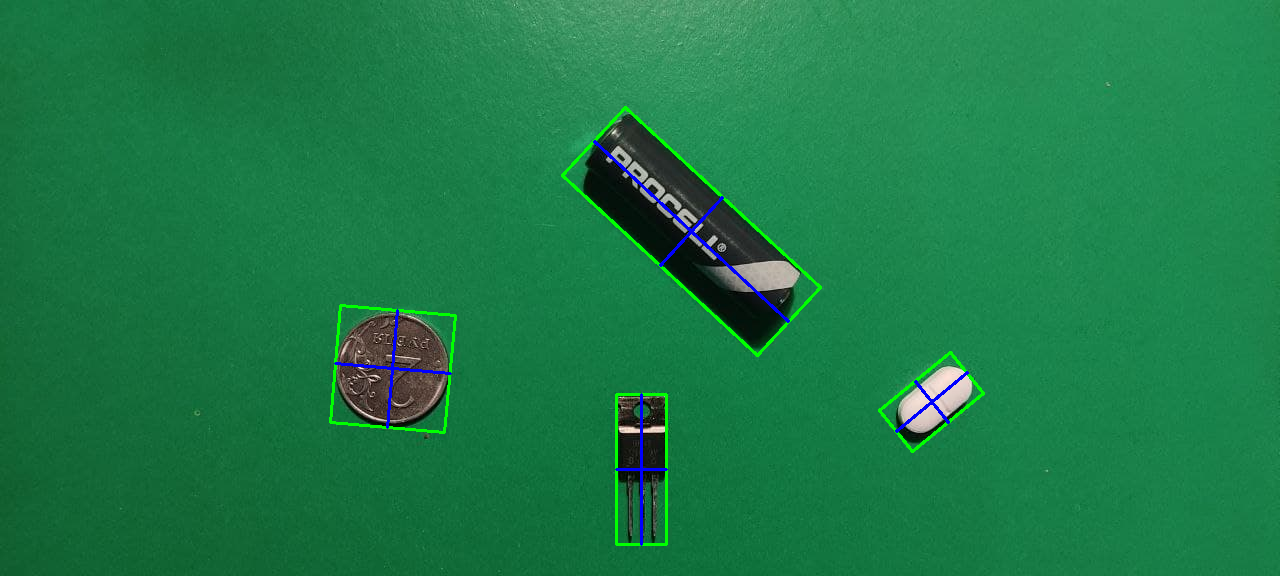

In [ ]:
orig = image.copy()
for c in cnts:
    if cv2.contourArea(c) < 1000:# пропускаем маленькие контуры
        continue

    box = cv2.minAreaRect(c)# вычисляем рамку ограничивающую контур

    box = cv2.cv.BoxPoints(box) if imutils.is_cv2() else cv2.boxPoints(box)# определяем углы

    box = perspective.order_points(box) # сортируем координаты по часовой стрелке

    cv2.drawContours(orig, [box.astype("int")], -1, (0, 255, 0), 2) # рисуем рамку, openCV  оперирует палитрой BGR

    # 4 средних точки габаритной рамки
    (tl, tr, br, bl) = box
    (tltrX, tltrY) = midpoint(tl, tr)
    (blbrX, blbrY) = midpoint(bl, br)
    (tlblX, tlblY) = midpoint(tl, bl)
    (trbrX, trbrY) = midpoint(tr, br)


    # средние линии синим цветом
    cv2.line(orig, (int(tltrX), int(tltrY)), (int(blbrX), int(blbrY)), (255, 0, 0), 2)
    cv2.line(orig, (int(tlblX), int(tlblY)), (int(trbrX), int(trbrY)), (255, 0, 0), 2)


cv2_imshow(orig)

Введем переменную, по смыслу похожую на выше обсуждавшуюся **pix_per_metric**. Т.к. наш эталонный предмет - монета - имеет размер в **мм**, то назовем ее **pixelsPerMillimetr**, а также введем параметр **width** - реальная ширина нашей монеты.

In [ ]:
pixelsPerMillimetr = None # инициализируем переменную pixelsPerMillimetr
width = 23.0

Снова дополним выше использовавшийся код, вычислим евклидово расстояние между средними точками, определим размер пикселя, а также рассчитаем и нанесем размеры объектов на изображение:

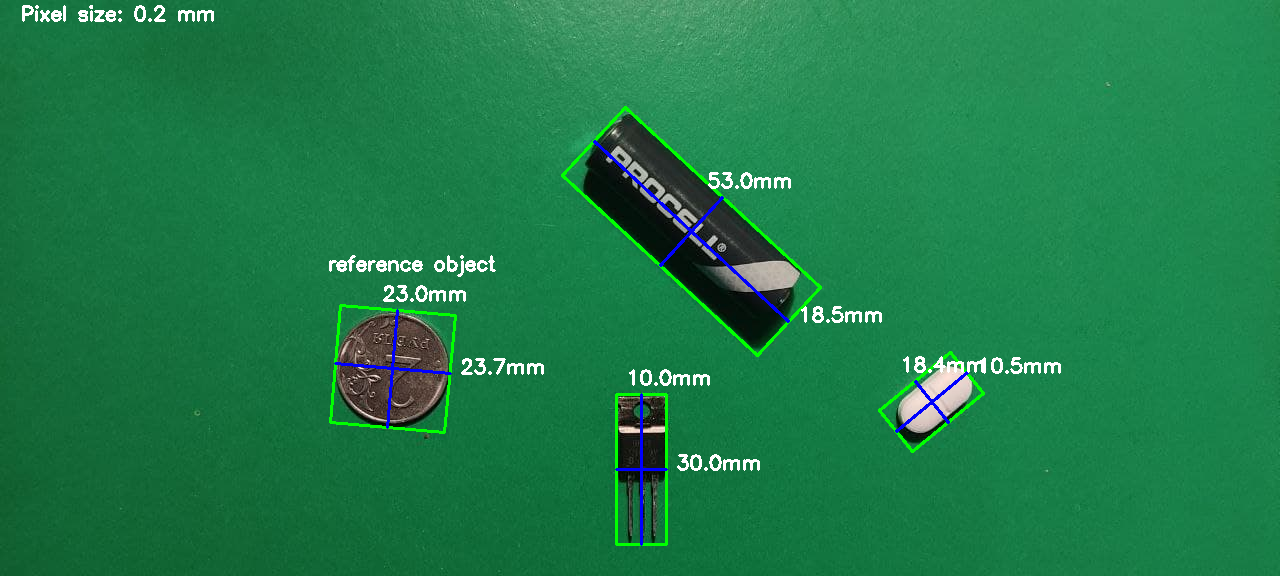

In [ ]:
orig = image.copy()
for c in cnts:
    if cv2.contourArea(c) < 1000:# пропускаем маленькие контуры
        continue

    box = cv2.minAreaRect(c)# вычисляем рамку ограничивающую контур

    box = cv2.cv.BoxPoints(box) if imutils.is_cv2() else cv2.boxPoints(box)# определяем углы

    box = perspective.order_points(box) # сортируем координаты по часовой стрелке

    cv2.drawContours(orig, [box.astype("int")], -1, (0, 255, 0), 2) # рисуем рамку, openCV  оперирует палитрой BGR

    # 4 средних точки габаритной рамки
    (tl, tr, br, bl) = box
    (tltrX, tltrY) = midpoint(tl, tr)
    (blbrX, blbrY) = midpoint(bl, br)
    (tlblX, tlblY) = midpoint(tl, bl)
    (trbrX, trbrY) = midpoint(tr, br)


    # средние линии синим цветом
    cv2.line(orig, (int(tltrX), int(tltrY)), (int(blbrX), int(blbrY)), (255, 0, 0), 2)
    cv2.line(orig, (int(tlblX), int(tlblY)), (int(trbrX), int(trbrY)), (255, 0, 0), 2)

    dA = dist.euclidean((tltrX, tltrY), (blbrX, blbrY))
    dB = dist.euclidean((tlblX, tlblY), (trbrX, trbrY))

    # Если переменная pixelsPerMillimetr неопределена, значит идет вычисление
    # самого левого объекта, который является эталонным и его размер известен
    if pixelsPerMillimetr is None:
        pixelsPerMillimetr = dB / width

        cv2.putText(orig, "reference object",
        (int(tltrX - 70), int(tltrY - 40)), cv2.FONT_HERSHEY_SIMPLEX,
        0.65, (255, 255, 255), 2)


    # вычисляем  размер пикселя
    dimA = dA / pixelsPerMillimetr
    dimB = dB / pixelsPerMillimetr

    # наносим размер объекта на изображение
    cv2.putText(orig, "{:.1f}mm".format(dimB),
        (int(tltrX - 15), int(tltrY - 10)), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (255, 255, 255), 2)

    cv2.putText(orig, "{:.1f}mm".format(dimA),
        (int(trbrX + 10), int(trbrY)), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (255, 255, 255), 2)

    #  выводим размер пикселя
    cv2.putText(orig, "Pixel size: {:.1f} mm".format(1/pixelsPerMillimetr),(20, 20), cv2.FONT_HERSHEY_SIMPLEX,
        0.65, (255, 255, 255), 2)

cv2_imshow(orig)